yt : [INFO     ] 2026-05-13 00:25:30,373 Parameters: current_time              = 2e-11
yt : [INFO     ] 2026-05-13 00:25:30,374 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-05-13 00:25:30,375 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-13 00:25:30,376 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]
yt : [INFO     ] 2026-05-13 00:25:30,508 xlim = -0.000000 0.000000
yt : [INFO     ] 2026-05-13 00:25:30,509 ylim = -0.000000 0.000000
yt : [INFO     ] 2026-05-13 00:25:30,512 xlim = -0.000000 0.000000
yt : [INFO     ] 2026-05-13 00:25:30,512 ylim = -0.000000 0.000000
yt : [INFO     ] 2026-05-13 00:25:30,515 Making a fixed resolution buffer of (('boxlib', 'Pz')) 800 by 800



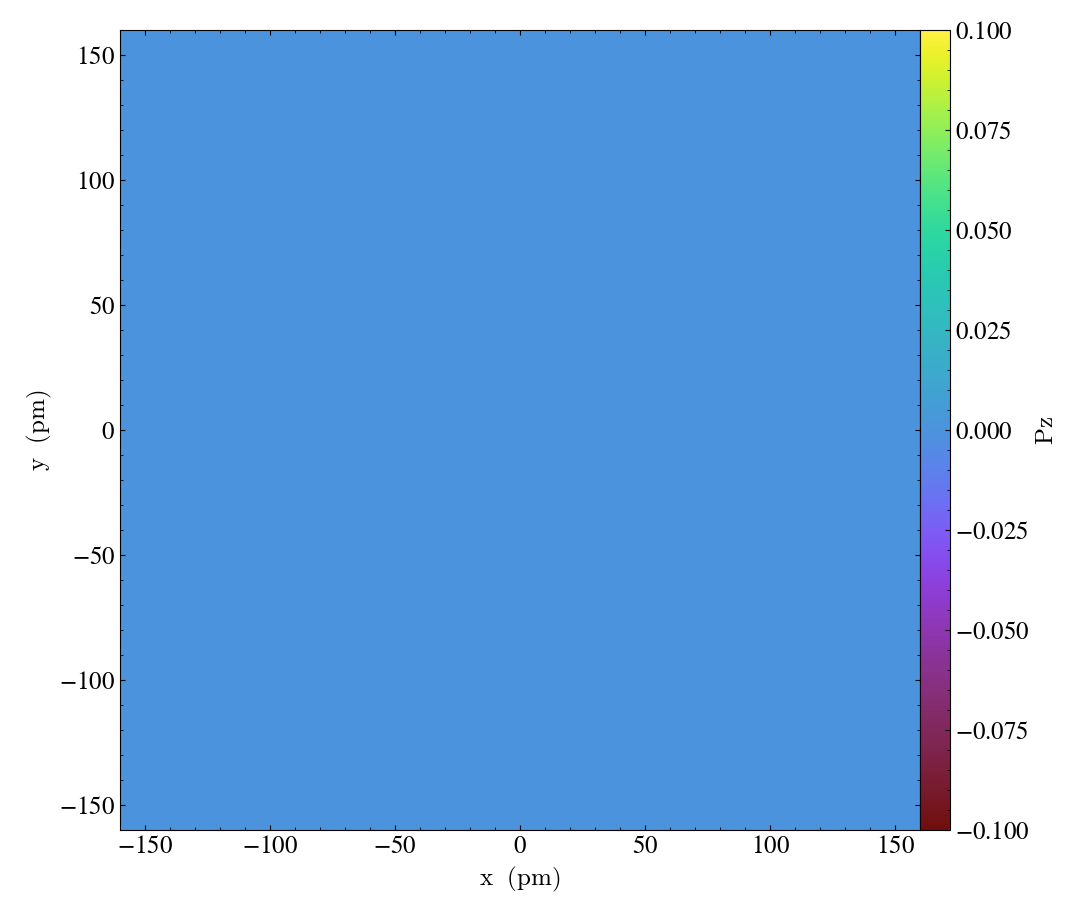

[('boxlib', 'Ex'), ('boxlib', 'Ey'), ('boxlib', 'Ez'), ('boxlib', 'Phi'), ('boxlib', 'PhiDiff'), ('boxlib', 'PoissonRHS'), ('boxlib', 'Px'), ('boxlib', 'Py'), ('boxlib', 'Pz'), ('boxlib', 'alpha'), ('boxlib', 'beta'), ('boxlib', 'charge'), ('boxlib', 'electrons'), ('boxlib', 'epsilon'), ('boxlib', 'holes'), ('boxlib', 'mask'), ('boxlib', 'theta'), ('boxlib', 'tphase')]
[('boxlib', 'Ex'), ('boxlib', 'Ey'), ('boxlib', 'Ez'), ('boxlib', 'Phi'), ('boxlib', 'PhiDiff'), ('boxlib', 'PoissonRHS'), ('boxlib', 'Px'), ('boxlib', 'Py'), ('boxlib', 'Pz'), ('boxlib', 'alpha'), ('boxlib', 'beta'), ('boxlib', 'cell_volume'), ('boxlib', 'charge'), ('boxlib', 'dx'), ('boxlib', 'dy'), ('boxlib', 'dz'), ('boxlib', 'electrons'), ('boxlib', 'epsilon'), ('boxlib', 'holes'), ('boxlib', 'mask'), ('boxlib', 'path_element_x'), ('boxlib', 'path_element_y'), ('boxlib', 'path_element_z'), ('boxlib', 'theta'), ('boxlib', 'tphase'), ('boxlib', 'volume'), ('boxlib', 'x'), ('boxlib', 'y'), ('boxlib', 'z'), ('gas', 'cel

In [1]:
import yt
import numpy as np
ds = yt.load('./FerroX/Exec/plt00000100/') # for data at time step 1000
#print(type(ds))
slc = yt.SlicePlot(ds, "z", "Pz",center='left')
slc.show()

#ds.print_stats()
print(ds.field_list)
print(ds.derived_field_list)
ad0 = ds.covering_grid(level=0, left_edge=ds.domain_left_edge, dims=ds.domain_dimensions)
P_array = ad0['Pz'].to_ndarray()
print(np.shape(P_array))

In [2]:
import yt
import numpy as np
import matplotlib.pyplot as plt

# 載入資料
ds = yt.load('./FerroX/Exec/plt00000100/')

# 取得 level 0 grid
ad0 = ds.covering_grid(
    level=0,
    left_edge=ds.domain_left_edge,
    dims=ds.domain_dimensions
)



yt : [INFO     ] 2026-05-13 00:25:37,418 Parameters: current_time              = 2e-11
yt : [INFO     ] 2026-05-13 00:25:37,419 Parameters: domain_dimensions         = [64 64 18]
yt : [INFO     ] 2026-05-13 00:25:37,419 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-05-13 00:25:37,420 Parameters: domain_right_edge         = [1.6e-08 1.6e-08 9.0e-09]


# Check Pz

(64, 64, 18)
z=0, Pz slice shape: (64, 64)


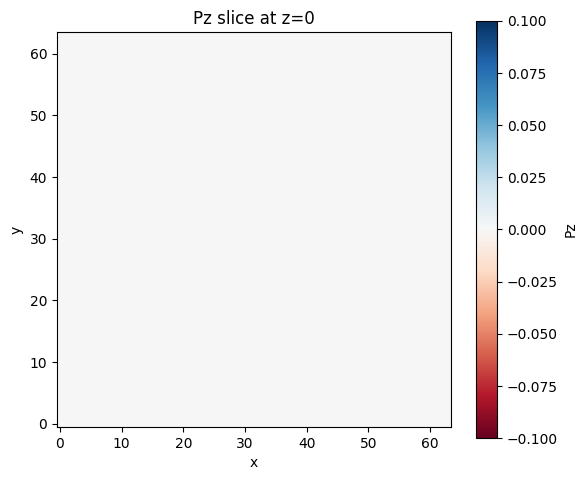

z=1, Pz slice shape: (64, 64)


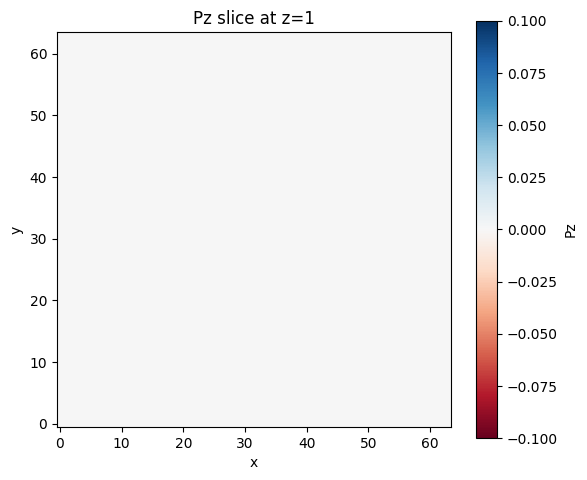

z=2, Pz slice shape: (64, 64)


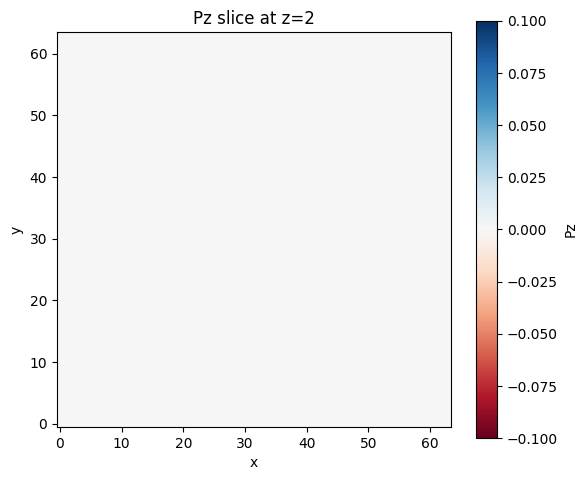

z=3, Pz slice shape: (64, 64)


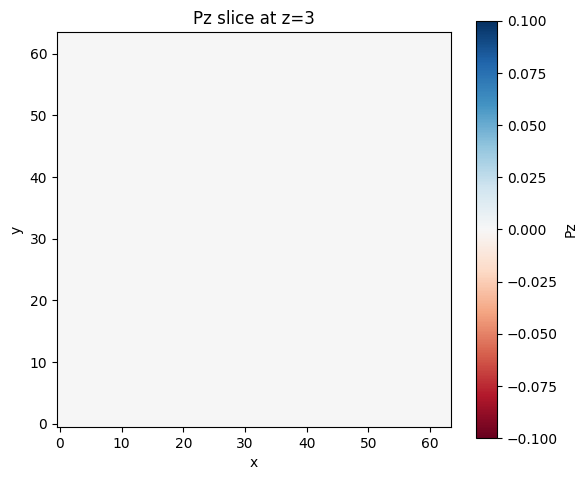

z=4, Pz slice shape: (64, 64)


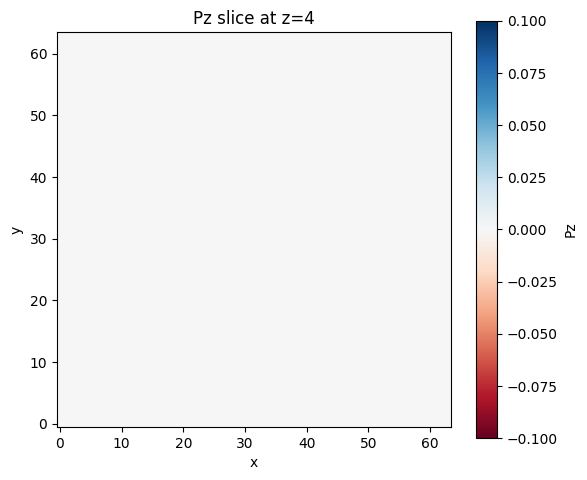

z=5, Pz slice shape: (64, 64)


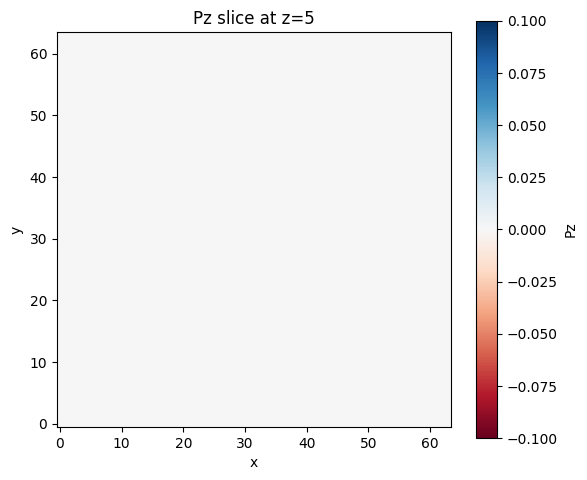

z=6, Pz slice shape: (64, 64)


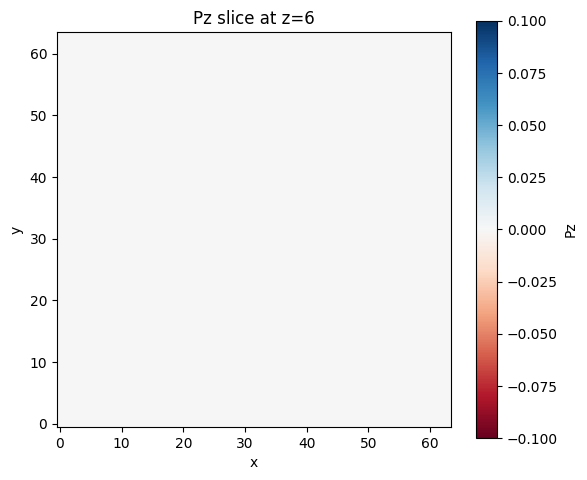

z=7, Pz slice shape: (64, 64)


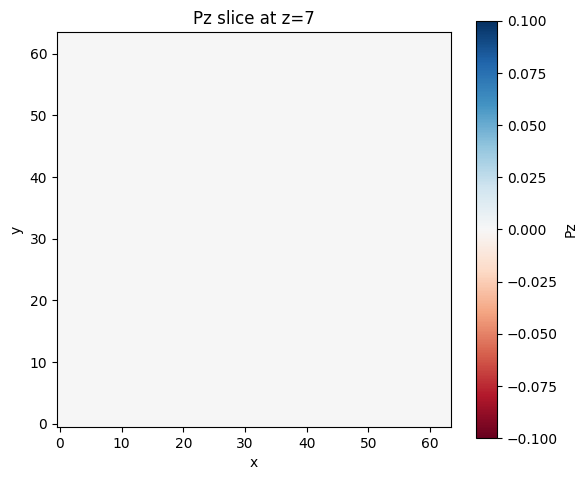

z=8, Pz slice shape: (64, 64)


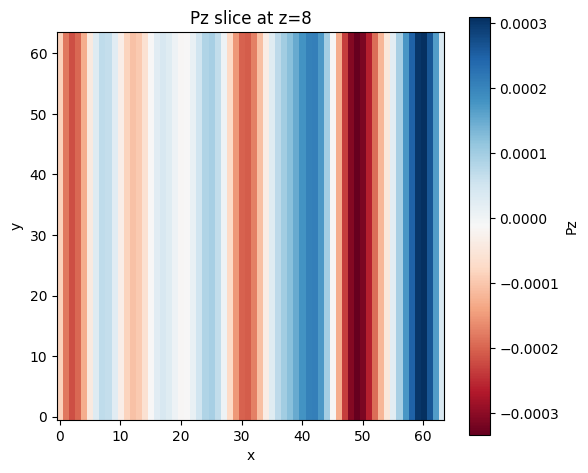

z=9, Pz slice shape: (64, 64)


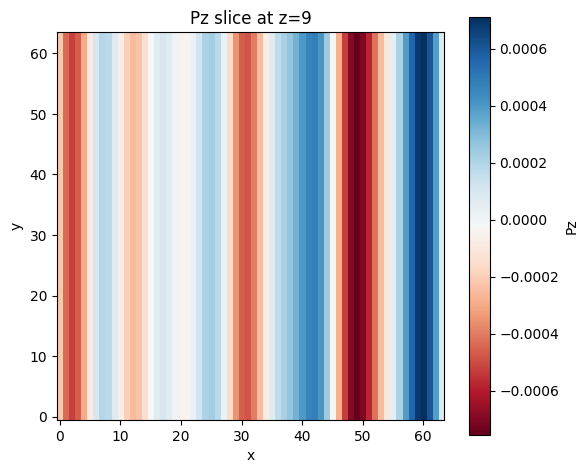

z=10, Pz slice shape: (64, 64)


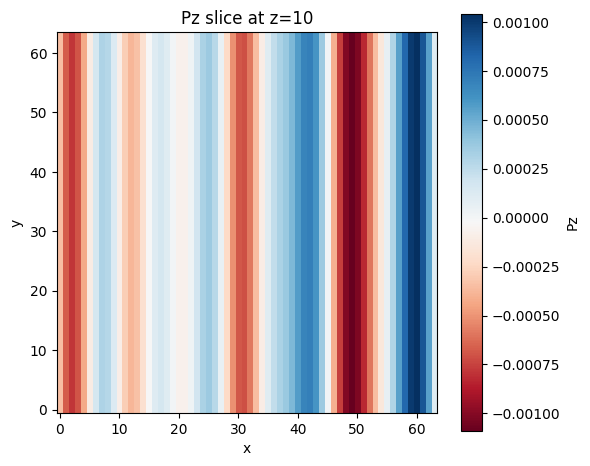

z=11, Pz slice shape: (64, 64)


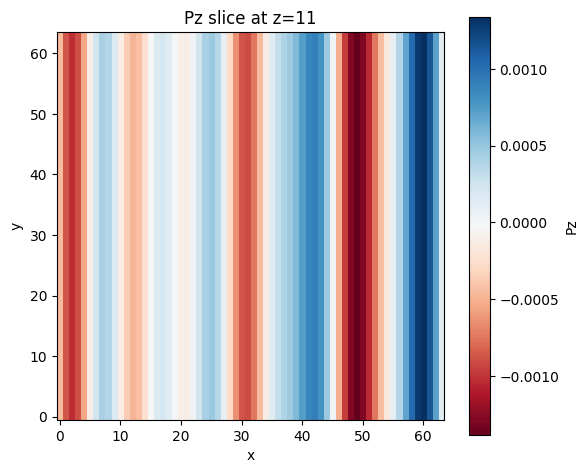

z=12, Pz slice shape: (64, 64)


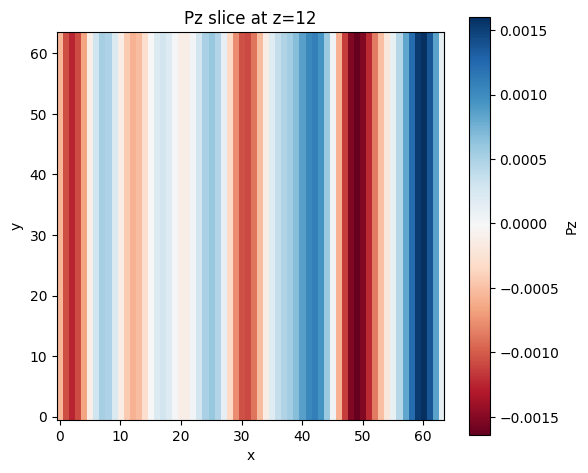

z=13, Pz slice shape: (64, 64)


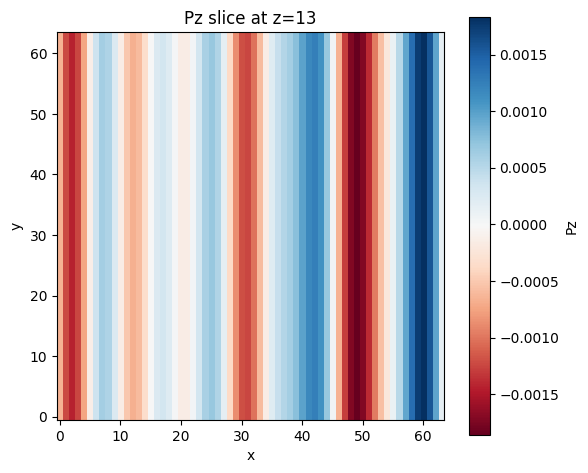

z=14, Pz slice shape: (64, 64)


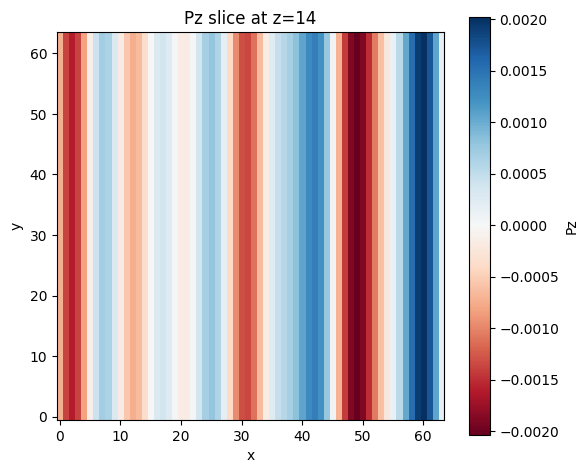

z=15, Pz slice shape: (64, 64)


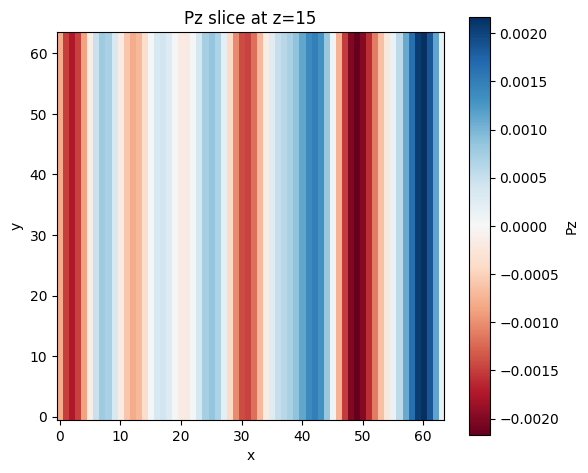

z=16, Pz slice shape: (64, 64)


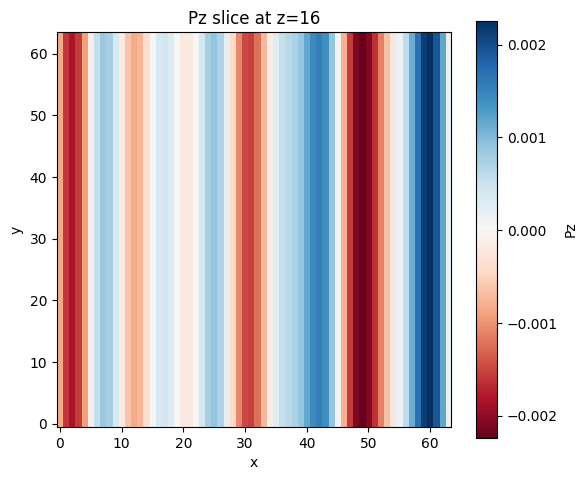

z=17, Pz slice shape: (64, 64)


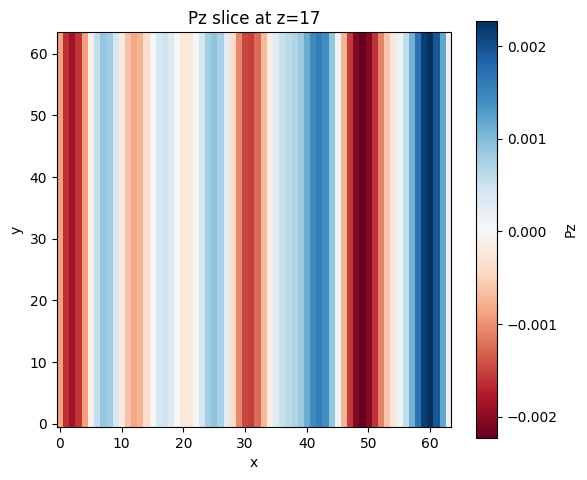

In [3]:
# 轉成 numpy array
P_array = ad0['Pz'].to_ndarray()

print(P_array.shape)

# ==========================================
# 假設資料 shape = (Nx, Ny, Nz)
# 在 z 方向取中間切面
# ==========================================
for z0 in range(P_array.shape[2]):
    print(f'z={z0}, Pz slice shape: {P_array[:, :, z0].shape}')
    z_mid = P_array.shape[2] // 2

    slice2d = P_array[:, :, z0]

    # 畫圖
    plt.figure(figsize=(6,5))

    im = plt.imshow(
        slice2d.T,          # transpose讓方向比較正常
        origin='lower',
        cmap='RdBu'
    )

    plt.colorbar(im, label='Pz')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Pz slice at z={z0}')

    plt.tight_layout()
    plt.show()

(64, 64, 18)
y=32, Py slice shape: (64, 18)


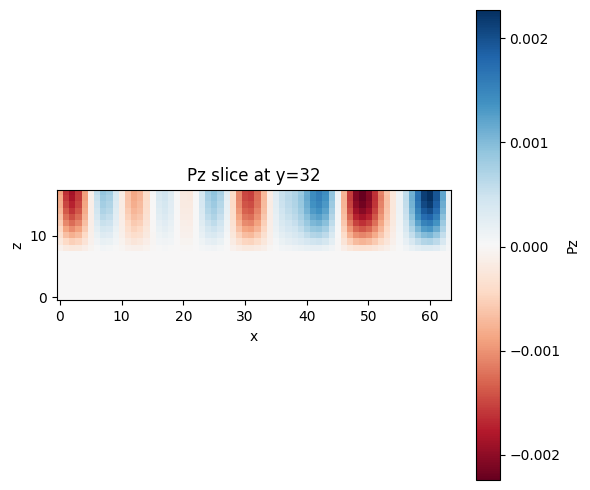

In [4]:
# 轉成 numpy array
P_array = ad0['Pz'].to_ndarray()

print(P_array.shape)

# ==========================================
# 假設資料 shape = (Nx, Ny, Nz)
# 在 z 方向取中間切面
# ==========================================
for y0 in range(P_array.shape[1]//2, P_array.shape[1]//2+1):
    print(f'y={y0}, Py slice shape: {P_array[:,  y0, :].shape}')
    z_mid = P_array.shape[2] // 2

    slice2d = P_array[:, y0, :]

    # 畫圖
    plt.figure(figsize=(6,5))

    im = plt.imshow(
        slice2d.T,          # transpose讓方向比較正常
        origin='lower',
        cmap='RdBu'
    )

    plt.colorbar(im, label='Pz')

    plt.xlabel('x')
    plt.ylabel('z')
    plt.title(f'Pz slice at y={y0}')

    plt.tight_layout()
    plt.show()

# Check Py

In [5]:
P_array = ad0['Px'].to_ndarray()
for c in P_array:
    for d in c:
        if d.any() != 0:
            print("ef")

(64, 64, 18)
z=0, Pz slice shape: (64, 64)


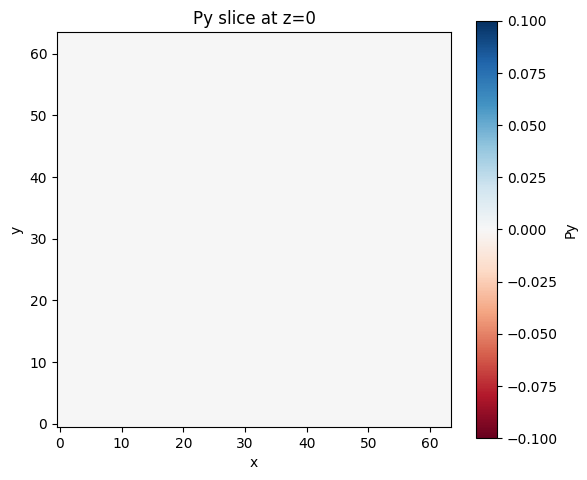

z=1, Pz slice shape: (64, 64)


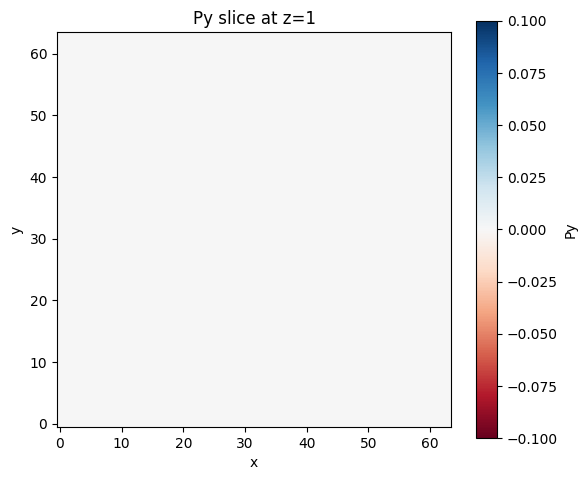

z=2, Pz slice shape: (64, 64)


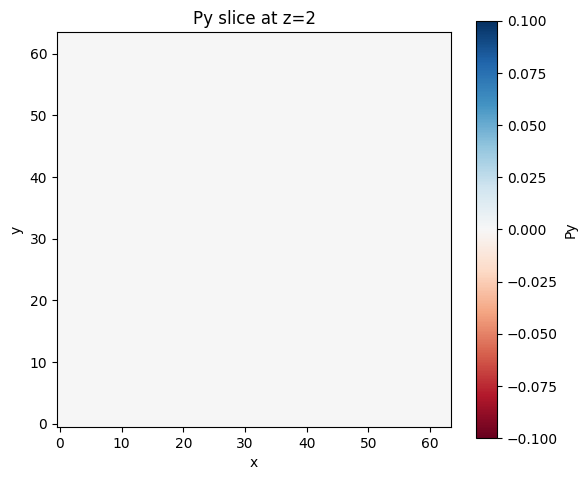

z=3, Pz slice shape: (64, 64)


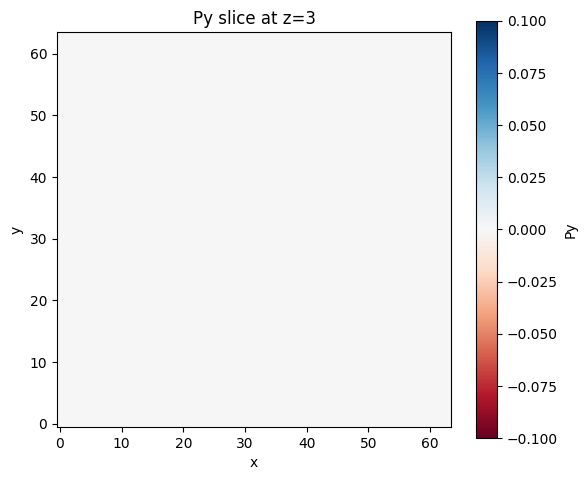

z=4, Pz slice shape: (64, 64)


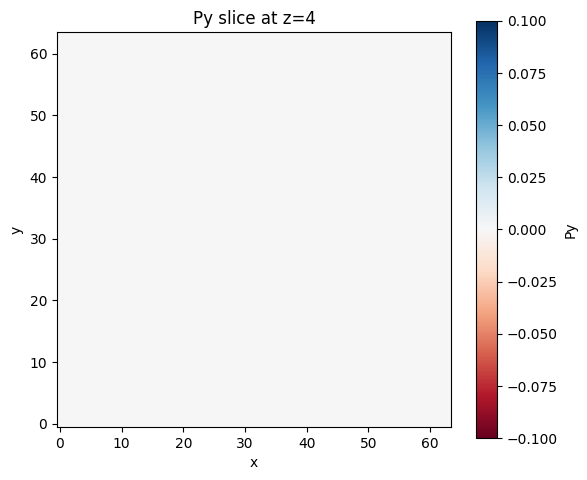

z=5, Pz slice shape: (64, 64)


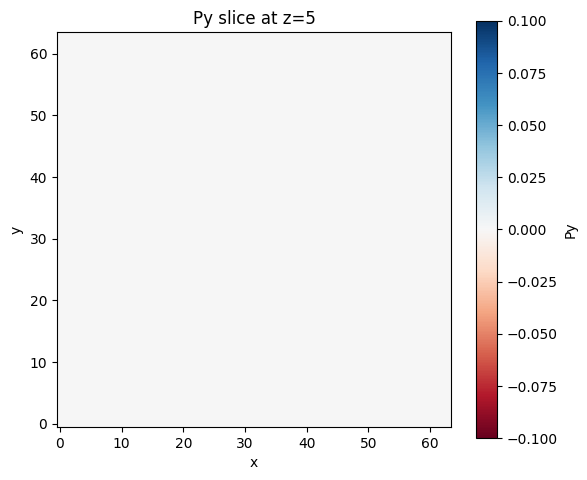

z=6, Pz slice shape: (64, 64)


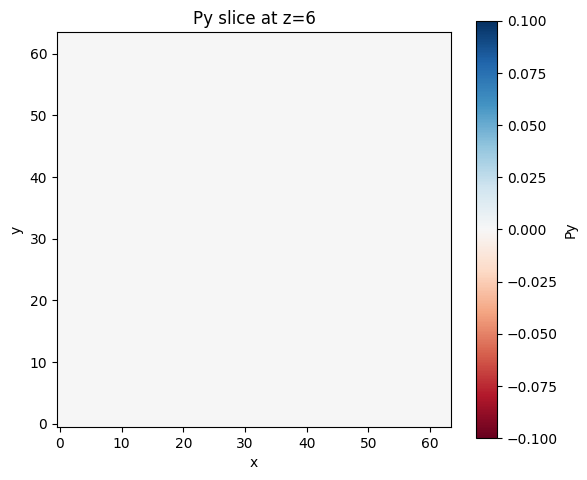

z=7, Pz slice shape: (64, 64)


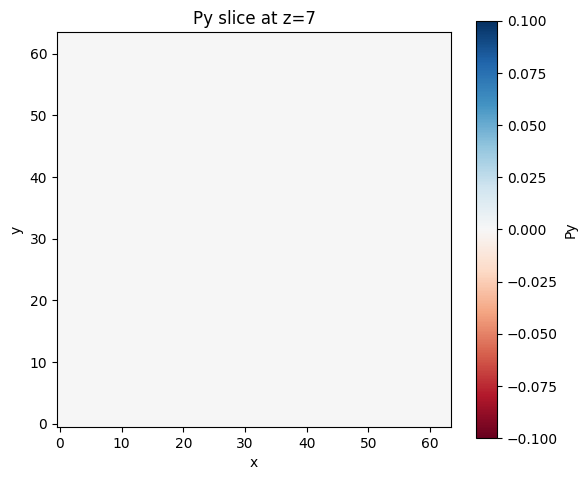

z=8, Pz slice shape: (64, 64)


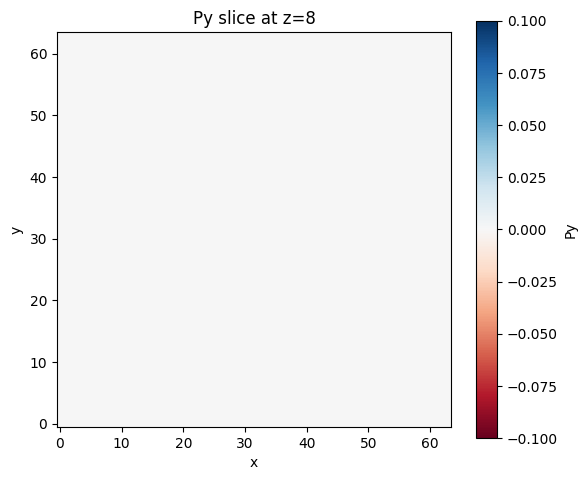

z=9, Pz slice shape: (64, 64)


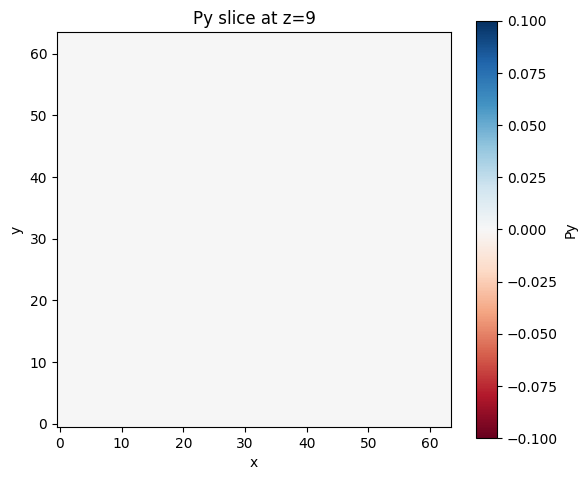

z=10, Pz slice shape: (64, 64)


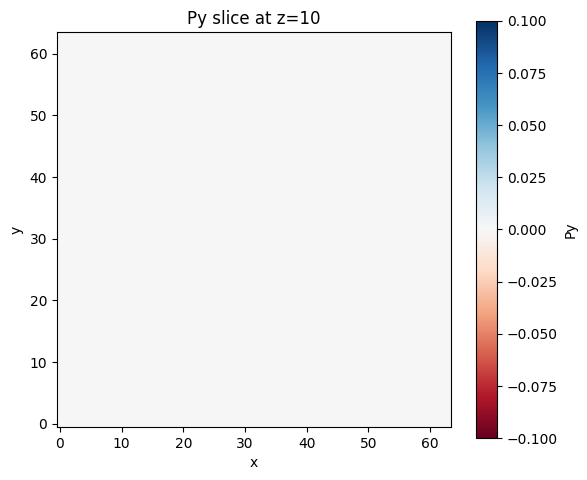

z=11, Pz slice shape: (64, 64)


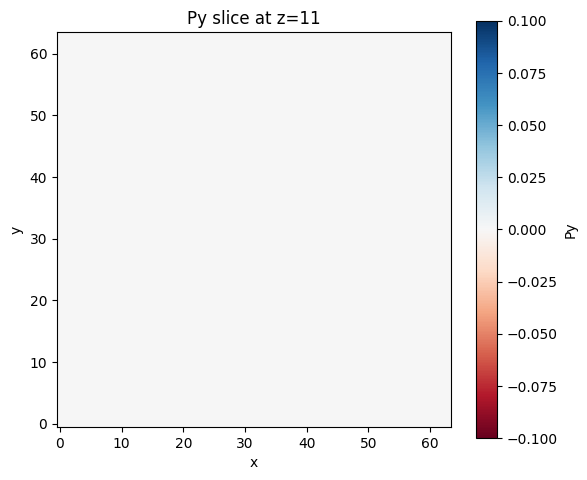

z=12, Pz slice shape: (64, 64)


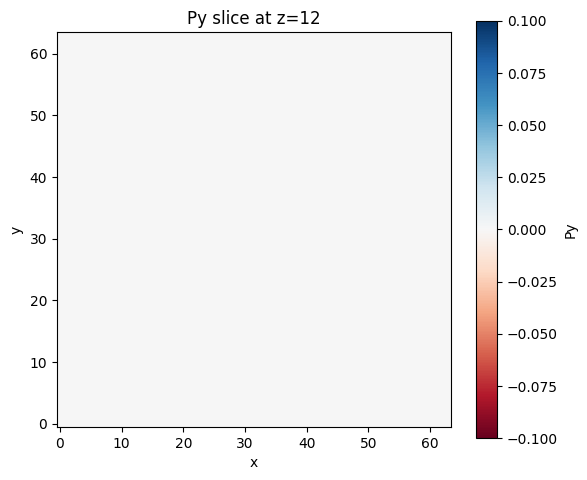

z=13, Pz slice shape: (64, 64)


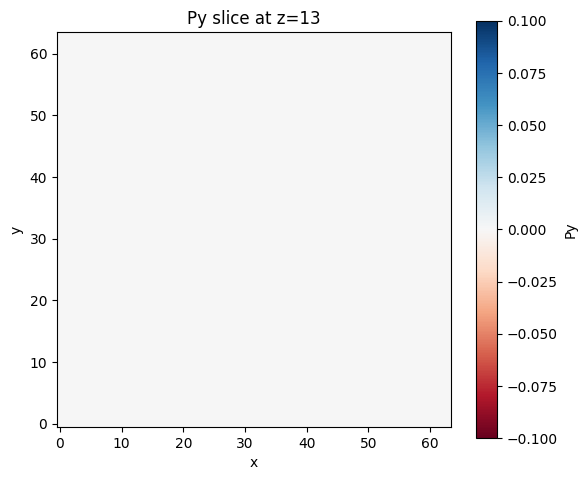

z=14, Pz slice shape: (64, 64)


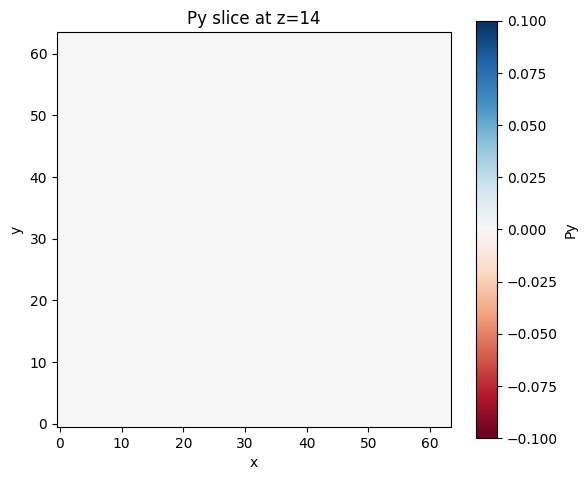

z=15, Pz slice shape: (64, 64)


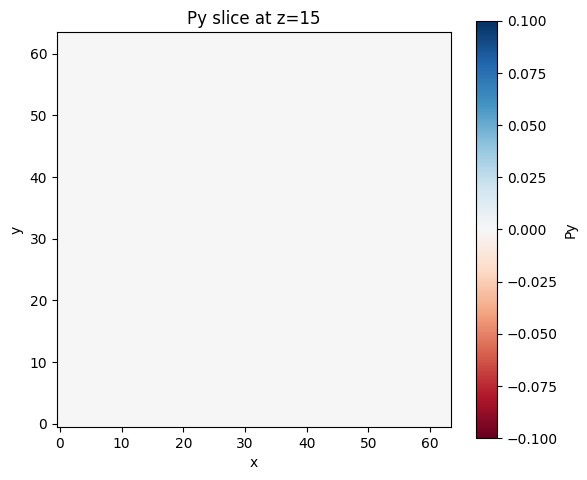

z=16, Pz slice shape: (64, 64)


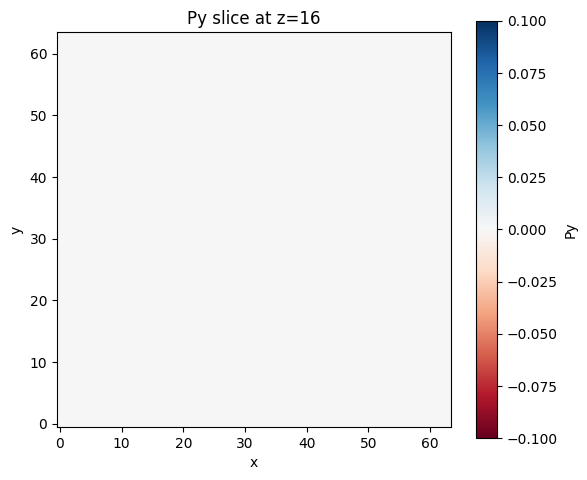

z=17, Pz slice shape: (64, 64)


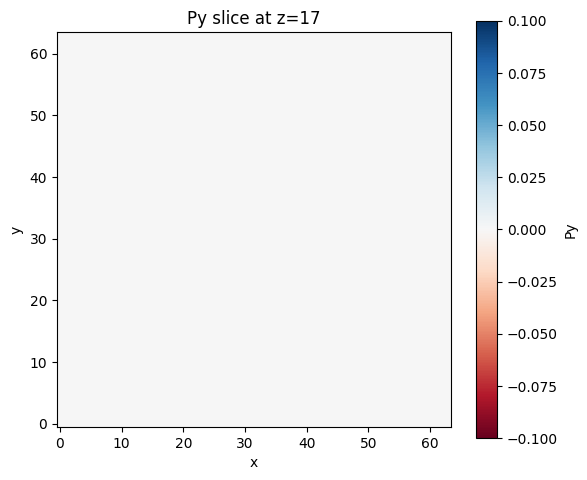

In [6]:
# 轉成 numpy array
P_array = ad0['Py'].to_ndarray()

print(P_array.shape)

# ==========================================
# 假設資料 shape = (Nx, Ny, Nz)
# 在 z 方向取中間切面
# ==========================================
for z0 in range(P_array.shape[2]):
    print(f'z={z0}, Pz slice shape: {P_array[:, :, z0].shape}')
    z_mid = P_array.shape[2] // 2

    slice2d = P_array[:, :, z0]

    # 畫圖
    plt.figure(figsize=(6,5))

    im = plt.imshow(
        slice2d.T,          # transpose讓方向比較正常
        origin='lower',
        cmap='RdBu'
    )

    plt.colorbar(im, label='Py')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Py slice at z={z0}')

    plt.tight_layout()
    plt.show()